# Bài tập Tuần 7 - CS116 - Nhóm 1
* Trần Thanh Tùng - 24521952
* Đặng Hoàng Long Vũ - 24522030
* Trần Thị Thùy Tiên - 23521588
* Nguyễn Thị Minh Phú - 23521186

### Import thư viện

In [13]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from datetime import datetime
import lightgbm as lgb


In [14]:
transactions_df = pl.read_parquet("transactions-2025-12.parquet")
transactions_df

customer_id,item_id,price,channel,payment,updated_date,location,quantity
i32,str,"decimal[38,4]",str,str,datetime[μs],i32,i32
8861340,"""0151000000003""",1625000.0000,"""In-Store""","""Tiền mặt""",2025-12-12 16:44:47.793,385,1
8680587,"""5074000000001""",139000.0000,"""SPE""","""Tiền mặt""",2025-12-01 10:28:50.830,1063,1
8220170,"""5856000000001""",480000.0000,"""SPE""","""Tiền mặt""",2025-12-23 09:20:27.653,416,1
7496264,"""6768000000002""",316200.0000,"""SPE""","""Tiền mặt""",2025-12-23 09:06:39.980,336,3
9170522,"""6904000000002""",840000.0000,"""SPE""","""Không xác định""",2025-12-23 09:24:55.640,601,1
…,…,…,…,…,…,…,…
9101369,"""2483000000004""",585000.0000,"""In-Store""","""Tiền mặt""",2025-12-08 06:49:12.620,970,1
9570455,"""6429000000002""",202500.0000,"""In-Store""","""Tiền mặt""",2025-12-08 06:48:30.790,1204,1
8693968,"""1512000000004""",284380.0000,"""SPE""","""Tiền mặt""",2025-12-08 18:58:51.597,1263,2


In [15]:
# Gom nhóm theo ngày để tạo chuỗi thời gian
daily_sales = transactions_df.group_by(["updated_date", "location", "item_id"]).agg([
    pl.col("quantity").sum().alias("qty"),
    pl.col("price").mean().alias("avg_price")
])

### Trực quan hóa dữ liệu

In [16]:
# Chuẩn bị dữ liệu cho các biểu đồ trực quan hóa
sns.set_theme(style='whitegrid')

# 1) Tổng số lượng bán theo tuần
weekly_total = (
    daily_sales
    .with_columns(pl.col("updated_date").dt.truncate("1w").alias("week_start"))
    .group_by("week_start")
    .agg(pl.col("qty").sum().alias("total_qty"))
    .sort("week_start")
)
weekly_total_pd = weekly_total.to_pandas()
weekly_total_pd["tuan"] = [f"Tuần {i+1}" for i in range(len(weekly_total_pd))]

# 2) Tổng sản lượng theo cửa hàng (top 10)
location_total_pd = (
    daily_sales
    .group_by("location")
    .agg(pl.col("qty").sum().alias("total_qty"))
    .sort("total_qty", descending=True)
    .head(10)
    .to_pandas()
)

# 3) Trung bình số lượng bán theo thứ trong tuần
dow_avg_pd = (
    daily_sales
    .with_columns(pl.col("updated_date").dt.weekday().alias("dow"))
    .group_by("dow")
    .agg(pl.col("qty").mean().alias("avg_qty"))
    .sort("dow")
    .to_pandas()
)
dow_map = {0: "Thứ 2", 1: "Thứ 3", 2: "Thứ 4", 3: "Thứ 5", 4: "Thứ 6", 5: "Thứ 7", 6: "Chủ nhật"}
dow_avg_pd["thu"] = dow_avg_pd["dow"].map(dow_map)


#### 1) Tổng số lượng bán theo tuần

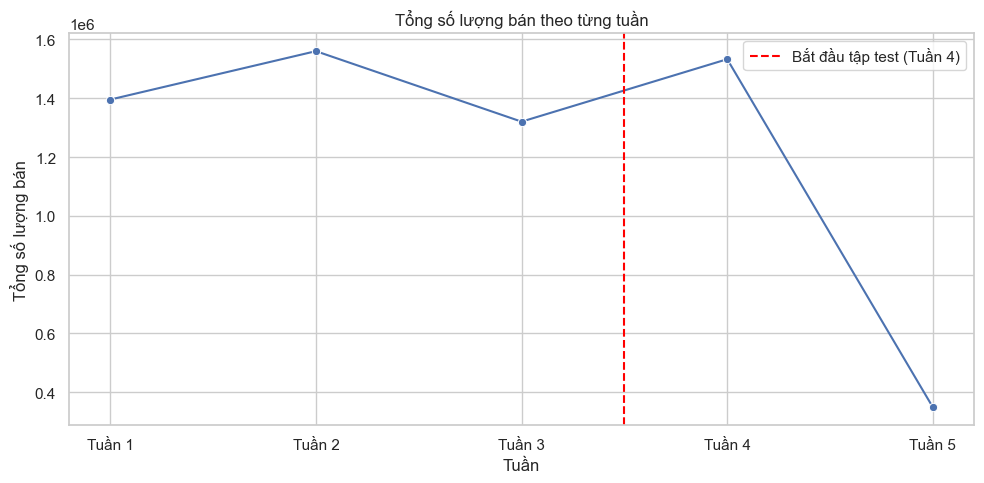

In [17]:
plt.figure(figsize=(10, 5))
ax = sns.lineplot(data=weekly_total_pd, x="tuan", y="total_qty", marker="o")
if len(weekly_total_pd) >= 4:
    ax.axvline(2.5, color="red", linestyle="--", label="Bắt đầu tập test (Tuần 4)")
plt.title("Tổng số lượng bán theo từng tuần")
plt.xlabel("Tuần")
plt.ylabel("Tổng số lượng bán")
plt.legend()
plt.tight_layout()
plt.show()


#### 2) Top 10 cửa hàng theo tổng số lượng bán

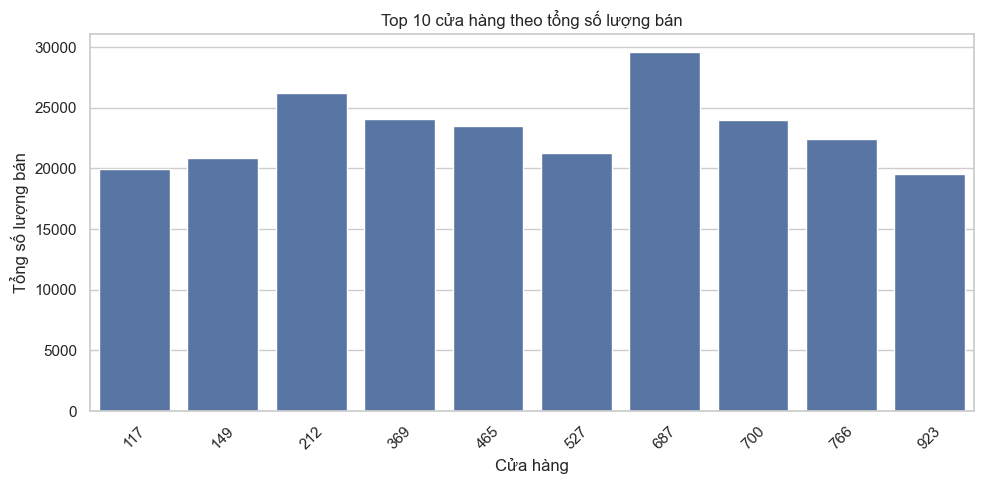

In [18]:
plt.figure(figsize=(10, 5))
sns.barplot(data=location_total_pd, x="location", y="total_qty")
plt.title("Top 10 cửa hàng theo tổng số lượng bán")
plt.xlabel("Cửa hàng")
plt.ylabel("Tổng số lượng bán")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### 3) Trung bình số lượng bán theo thứ trong tuần

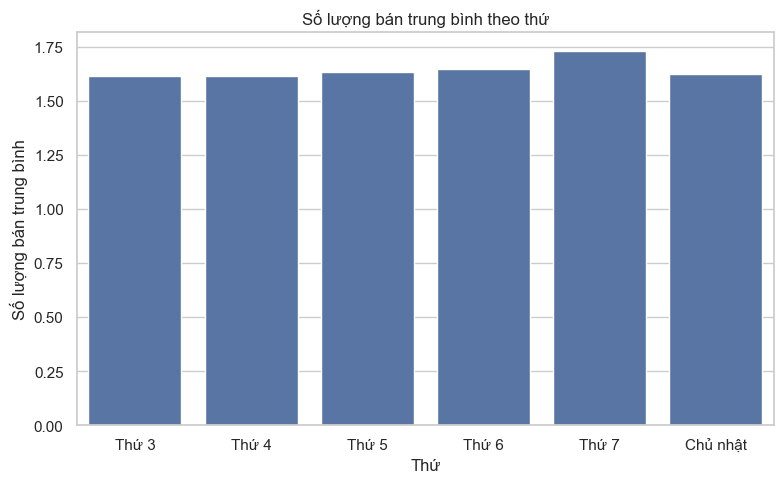

In [19]:
plt.figure(figsize=(8, 5))
sns.barplot(data=dow_avg_pd, x="thu", y="avg_qty")
plt.title("Số lượng bán trung bình theo thứ")
plt.xlabel("Thứ")
plt.ylabel("Số lượng bán trung bình")
plt.tight_layout()
plt.show()


#### 4) So sánh ngẫu nhiên theo tuần

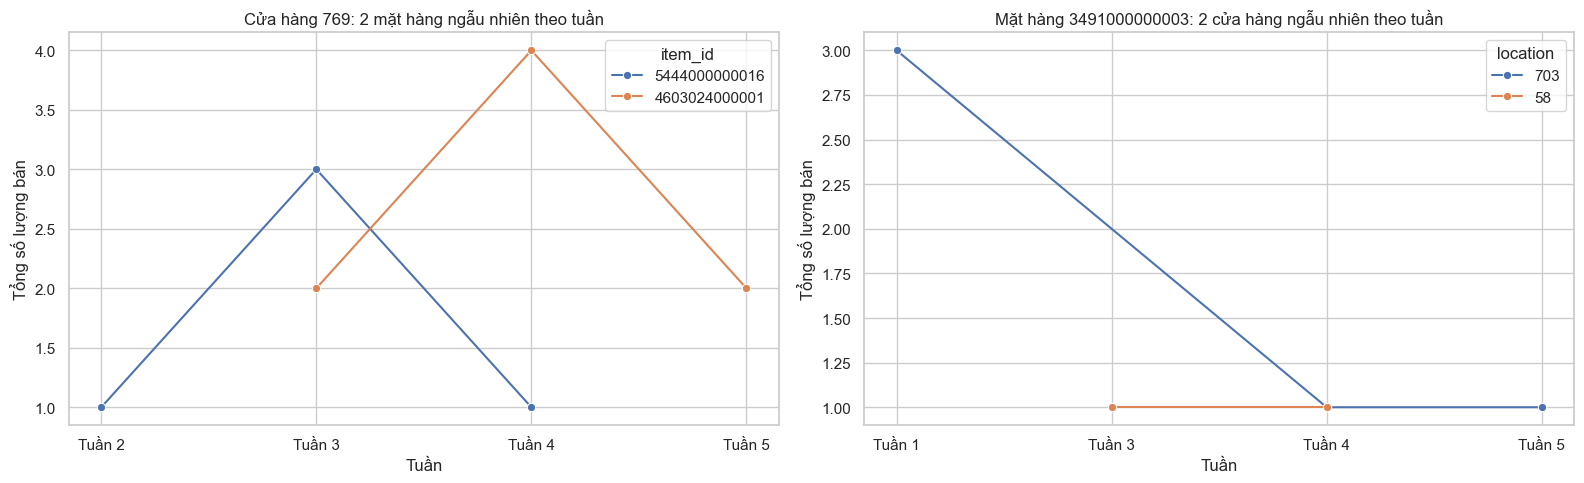

In [20]:
# Tao bang doanh so theo tuan- cua hang- san pham
weekly_detail = (
    daily_sales
    .with_columns(pl.col("updated_date").dt.truncate("1w").alias("week_start"))
    .group_by(["week_start", "location", "item_id"])
    .agg(pl.col("qty").sum().alias("total_qty"))
    .sort(["week_start", "location", "item_id"])
)
weekly_detail_pd = weekly_detail.to_pandas()

# Tao nhan Tuần 1, Tuần 2, ... cho truc hoanh
week_order = sorted(weekly_detail_pd["week_start"].dropna().unique())
week_map = {w: f"Tuần {i+1}" for i, w in enumerate(week_order)}
weekly_detail_pd["tuan"] = weekly_detail_pd["week_start"].map(week_map)

# Random seed theo thoi diem de moi lan chay co the ra cap khac nhau
seed = int(pd.Timestamp.now().value % (2**32 - 1))

# Bieu do A: 1 cua hang + 2 item (moi item co it nhat 2 tuan du lieu)
li_weeks = (
    weekly_detail_pd.groupby(["location", "item_id"])["tuan"]
    .nunique()
    .reset_index(name="so_tuan")
)
good_li = li_weeks[li_weeks["so_tuan"] >= 2]
loc_pool = (
    good_li.groupby("location")["item_id"]
    .nunique()
    .reset_index(name="so_item")
    .query("so_item >= 2")
)

plot_a = None
title_a = "Không đủ dữ liệu cho biểu đồ 1 cửa hàng - 2 mặt hàng"
if not loc_pool.empty:
    chosen_location = loc_pool.sample(1, random_state=seed)["location"].iloc[0]
    item_pool = good_li[good_li["location"] == chosen_location]["item_id"].drop_duplicates()
    chosen_items = item_pool.sample(2, random_state=seed).tolist()
    plot_a = weekly_detail_pd[(weekly_detail_pd["location"] == chosen_location) & (weekly_detail_pd["item_id"].isin(chosen_items))].copy()
    plot_a = plot_a.sort_values(["week_start", "item_id"])
    plot_a["item_id"] = plot_a["item_id"].astype(str)
    title_a = f"Cửa hàng {chosen_location}: 2 mặt hàng ngẫu nhiên theo tuần"

# Bieu do B: 1 item + 2 cua hang (moi cua hang co it nhat 2 tuan du lieu)
il_weeks = (
    weekly_detail_pd.groupby(["item_id", "location"])["tuan"]
    .nunique()
    .reset_index(name="so_tuan")
)
good_il = il_weeks[il_weeks["so_tuan"] >= 2]
item_pool = (
    good_il.groupby("item_id")["location"]
    .nunique()
    .reset_index(name="so_location")
    .query("so_location >= 2")
)

plot_b = None
title_b = "Không đủ dữ liệu cho biểu đồ 1 mặt hàng - 2 cửa hàng"
if not item_pool.empty:
    chosen_item = item_pool.sample(1, random_state=seed)["item_id"].iloc[0]
    loc_pool_b = good_il[good_il["item_id"] == chosen_item]["location"].drop_duplicates()
    chosen_locations = loc_pool_b.sample(2, random_state=seed).tolist()
    plot_b = weekly_detail_pd[(weekly_detail_pd["item_id"] == chosen_item) & (weekly_detail_pd["location"].isin(chosen_locations))].copy()
    plot_b = plot_b.sort_values(["week_start", "location"])
    plot_b["location"] = plot_b["location"].astype(str)
    title_b = f"Mặt hàng {chosen_item}: 2 cửa hàng ngẫu nhiên theo tuần"

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

if plot_a is not None and not plot_a.empty:
    sns.lineplot(data=plot_a, x="tuan", y="total_qty", hue="item_id", marker="o", ax=axes[0])
    axes[0].set_title(title_a)
    axes[0].set_xlabel("Tuần")
    axes[0].set_ylabel("Tổng số lượng bán")
else:
    axes[0].text(0.5, 0.5, title_a, ha="center", va="center")
    axes[0].set_axis_off()

if plot_b is not None and not plot_b.empty:
    sns.lineplot(data=plot_b, x="tuan", y="total_qty", hue="location", marker="o", ax=axes[1])
    axes[1].set_title(title_b)
    axes[1].set_xlabel("Tuần")
    axes[1].set_ylabel("Tổng số lượng bán")
else:
    axes[1].text(0.5, 0.5, title_b, ha="center", va="center")
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()


In [21]:
# Gom nhóm theo ngày để tạo chuỗi thời gian
transactions_df = transactions_df.with_columns(
    pl.col("updated_date").dt.date().alias("date")
)

daily_sales = transactions_df.group_by(["date", "location", "item_id"]).agg([
    pl.col("quantity").sum().alias("qty"),
    pl.col("price").mean().alias("avg_price")
])

### Tạo Features

In [22]:

def make_features(data):
    return data.with_columns([
        pl.col("date").dt.weekday().alias("dow"),
        pl.col("date").dt.day().alias("day"),
        (pl.col("date").dt.weekday() > 5).cast(pl.Int32).alias("is_weekend")
    ])

full_df = make_features(daily_sales)

### Chia tập dữ liệu 

In [23]:
# Chia tập Train (trước 22/12) và Test (từ 22/12)
train_data = full_df.filter(pl.col("date") < datetime(2025, 12, 22).date())
test_data = full_df.filter(pl.col("date") >= datetime(2025, 12, 22).date())


## Tính toán Dự báo (Prediction)

In [24]:


# Chuẩn bị dữ liệu cho LightGBM
features = ["location", "item_id", "avg_price", "dow", "day", "is_weekend"]
target = "qty"

# Chuyển sang định dạng Numpy/Pandas để đưa vào model (LGBM chưa hỗ trợ trực tiếp Polars)
X_train = train_data.select(features).to_pandas()
y_train = train_data.select(target).to_pandas()
X_test = test_data.select(features).to_pandas()
y_test = test_data.select(target).to_pandas()

# Định nghĩa category để model hiểu
cat_features = ["location", "item_id"]
for col in cat_features:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

# 4. Huấn luyện mô hình với mục tiêu tối ưu MAE
model = lgb.LGBMRegressor(
    objective='regression_l1', # l1 chính là tối ưu cho MAE
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], 
          eval_metric='mae', callbacks=[lgb.early_stopping(stopping_rounds=50)])

# 5. Dự đoán và tổng hợp kết quả
test_data = test_data.with_columns(
    pl.Series(name="pred_qty", values=model.predict(X_test))
)

# Gom nhóm kết quả dự đoán cho cả giai đoạn 22/12 -> 31/12
final_prediction = (
    test_data.group_by(["location", "item_id"])
    .agg(pl.col("pred_qty").sum().alias("qty"))
)

# Tính MAE cuối cùng
actual_totals = test_data.group_by(["location", "item_id"]).agg(pl.col("qty").sum().alias("actual_qty"))
comparison = final_prediction.join(actual_totals, on=["location", "item_id"])
mae_score = (comparison["qty"] - comparison["actual_qty"]).abs().mean()

print(f"MAE của mô hình LightGBM: {mae_score:.4f}")


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.054134 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5141
[LightGBM] [Info] Number of data points in the train set: 2235140, number of used features: 6
[LightGBM] [Info] Start training from score 1.000000
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's l1: 0.749763
MAE của mô hình LightGBM: 1.0824


In [25]:

# Làm sạch bảng dự báo (location, item_id, qty)
final_prediction_table = (
    final_prediction
    .select([
        pl.col("location"),
        pl.col("item_id"),
        pl.col("qty").round(0).cast(pl.Int32) # Làm tròn để thực tế hơn cho việc nhập hàng
    ])
    .sort(["location", "qty"], descending=[False, True])
)

# Hiển thị kết quả dự báo 
print(final_prediction_table)
# Xuất ra file:
final_prediction_table.write_parquet("submission.parquet")

# 3. Tính toán MAE trên toàn bộ sản phẩm và cửa hàng
mae_final = (
    comparison
    .with_columns(
        (pl.col("qty") - pl.col("actual_qty")).abs().alias("abs_error")
    )
    ["abs_error"].mean()
)

print("\n--- ĐÁNH GIÁ MÔ HÌNH ---")
print(f"MAE trên toàn bộ hệ thống: {mae_final:.4f}")


shape: (627_813, 3)
┌──────────┬───────────────┬─────┐
│ location ┆ item_id       ┆ qty │
│ ---      ┆ ---           ┆ --- │
│ i32      ┆ str           ┆ i32 │
╞══════════╪═══════════════╪═════╡
│ 42       ┆ 4690000000001 ┆ 33  │
│ 42       ┆ 6697000000003 ┆ 32  │
│ 42       ┆ 7176000000002 ┆ 30  │
│ 42       ┆ 6751000000002 ┆ 19  │
│ 42       ┆ 7176000000004 ┆ 19  │
│ …        ┆ …             ┆ …   │
│ 1398     ┆ 5444000000007 ┆ 1   │
│ 1398     ┆ 0029140000027 ┆ 1   │
│ 1398     ┆ 0949000000066 ┆ 1   │
│ 1398     ┆ 0179000000021 ┆ 1   │
│ 1398     ┆ 1371000000004 ┆ 1   │
└──────────┴───────────────┴─────┘

--- ĐÁNH GIÁ MÔ HÌNH ---
MAE trên toàn bộ hệ thống: 1.0824
